<h1 style="color: #663399">
    Video Game Sales Analysis and Market Insights


</h1>

<h2 style="color: #808080; font-weight: normal; margin-top: -10px; font-size:18px">
    ANÁLISIS DE VENTA DE VIDEOJUEGOS DE ICE | TripleTen Data Science Bootcamp (2025)
</h2>

<h1 style="color: #9370DB; font-size:18px">
    Librerias
</h1>
Primero se llaman a las librerias necesarias para el desarrollo del proyecto.

In [8]:
# Librerias necesarias
import pandas as pd
import numpy as np
import math as mt
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
palette = sns.color_palette("pastel")
from scipy import stats as st

<h1 style="color: #9370DB; font-size:18px">
    Dataset
</h1>
A continuación se preparan los datos para su análisis. Abriendo primero el archivo y estudiando sus características.

In [9]:
# Dataset
df = pd.read_csv('games.csv')
df.info()
df.nunique()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 2.0 MB


Name               11559
Platform              31
Year_of_Release       37
Genre                 12
NA_sales             402
EU_sales             307
JP_sales             244
Other_sales          155
Critic_Score          82
User_Score            96
Rating                 8
dtype: int64

<h1 style="color: #9370DB; font-size:18px">
    Preparación de los datos
</h1>
Lo principal
 para cumplir con las reglas del snake_case es pasar los nombres de las columnas a minúsculas. Después debemos quitar los valores ausentes, rellenandolos con valores adecuados para las condiciones de cada columna. Finalmente nos aseguramos de que cada columna sea del tipo adecuado para su análisis posterior.

In [10]:
# Minúsculas
df.columns = [col.lower() for col in df.columns]
print(df.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='str')


Como precaución confirmamos que no haya filas duplicadas.

In [11]:
# Duplicados
duplicados = df.duplicated().sum()
if duplicados > 0:
    print(f"Hay {duplicados} duplicados")
else:
    print("No hay duplicados")

No hay duplicados


Ya que confirmamos que no hay duplicados, comenzamos a trabajar los valores ausentes y el tipo de datos. Comenzamos con los dos valores ausentes en 'name' y en 'genre', comprobando si corresponden a la misma fila, ya que esto podría explicar porque si no tenemos el nomnbre, no tenemos el género.

In [12]:
# Valores ausentes en 'name' y 'genre'
df[df['name'].isna() | df['genre'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


Una vez comprobado que si corresponden a la misma fila podemos sustituir por 'UNKNOWN' es decir DESCONOCIDO. El tipo de datos object es adecuado.

In [13]:
# Sustitución de valores ausentes en 'name' y en 'genre'
df['name'] = df['name'].fillna('Unknown')
df['genre'] = df['genre'].fillna('Unknown')

Para los años primero comprobamos que valores se encuentran en la columna.

In [14]:
# Valores únicos en la columna 'year_of_release' 
print(sorted(df['year_of_release'].dropna().unique().tolist()))

[1980.0, 1981.0, 1982.0, 1983.0, 1984.0, 1985.0, 1986.0, 1987.0, 1988.0, 1989.0, 1990.0, 1991.0, 1992.0, 1993.0, 1994.0, 1995.0, 1996.0, 1997.0, 1998.0, 1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0, 2016.0]


Vemos que hay valores ininterrumpidos de 1980 hasta 2016. Ya que hay 269 valores faltantes, podemos sustituir por 0, para poder cambiar el tipo de valor a entero y poder hacer más adelante una categoría de año desconocido y ver si es relevante el año de lanzamiento, así como conocerlo.

In [15]:
# Sustitución de valores en 'year_of_release' y cambio de tipo de datos a entero  
df['year_of_release'] = df['year_of_release'].fillna(0) # 0 : no hay valor para el año de lanzamiento
df['year_of_release'] = df['year_of_release'].astype('int')
print(sorted(df['year_of_release'].unique().tolist()))

[0, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]


Lo siguiente es determinar los valores para sustituir los ausentes para critic_score, user_score y rating.

In [16]:
# Valores únicos en las columnas 'critic_score', 'user_score' y 'rating'
print(sorted(df['critic_score'].dropna().unique().tolist()))
print(sorted(df['user_score'].dropna().unique().tolist()))
print(sorted(df['rating'].dropna().unique().tolist()))

[13.0, 17.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0]
['0', '0.2', '0.3', '0.5', '0.6', '0.7', '0.9', '1', '1.1', '1.2', '1.3', '1.4', '1.5', '1.6', '1.7', '1.8', '1.9', '2', '2.1', '2.2', '2.3', '2.4', '2.5', '2.6', '2.7', '2.8', '2.9', '3', '3.1', '3.2', '3.3', '3.4', '3.5', '3.6', '3.7', '3.8', '3.9', '4', '4.1', '4.2', '4.3', '4.4', '4.5', '4.6', '4.7', '4.8', '4.9', '5', '5.1', '5.2', '5.3', '5.4', '5.5', '5.6', '5.7', '5.8', '5.9', '6', '6.1', '6.2', '6.3', '6.4', '6.5', '6.6', '6.7', '6.8', '6.9', '7', '7.1', '7.2', '7.3', '7.4', '7.5', '7.6', '7.7

Para 'critic_score': Ya que el valor más bajo que se registró fue 13.0, se puede usar 0 al igual que el año de lanzamiento, para los valores ausentes, es decir aquellos que no tienen score de los crítico. El tipo de dato se cambia a entero.

Para 'user_score': En este caso, el rango de calificaciones van de 0.0 a 10.0, por lo que no se puede usar el 0 al igual que las otras columnas, pero se puede usar un número fuera del score (como el 11.0) para sustituir tanto los ausentes como los 'tbd' es decir los que estan por definirse, ya que al final del 2016 al momento de reunir los datos no sé cuenta con la calificación. Con el valor nuevo se van a poder aislar más adelante. El tipo de dato se cambia a float.

Para 'rating': En este caso se puede utilizar 'UK' de Unknown para los de rating desconocido. El tipo de dato es correcto.

In [17]:
# Llenado de valores ausentes y correccion de tipo
# Para critic_score
df['critic_score'] = df['critic_score'].fillna(0) # 0 = no tiene score
df['critic_score'] = df['critic_score'].astype('int')

# Para user_score
df['user_score'] = df['user_score'].replace('tbd', 11.0)
df['user_score'] = df['user_score'].fillna(11.0) # 11 = no tiene score
df['user_score'] = df['user_score'].astype('float')

#Para rating
df['rating'] = df['rating'].fillna('UK') # UK = clasificación (rating) desconocido

Con estos cambios ya no debe haber valores ausentes y todas las columnas deben ser del tipo de dato adecuado, dejando los datos listos para trabajar con ellos y realizar los análisis posteriores.

In [18]:
# Confirmamos los datos están listos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16715 non-null  int64  
 3   genre            16715 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  int64  
 9   user_score       16715 non-null  float64
 10  rating           16715 non-null  str    
dtypes: float64(5), int64(2), str(4)
memory usage: 2.0 MB


Finalmente vamos a agregar una columna que será de utilidad más adelante. Vamos a agregar la suma de las ventas de Norteamérica, Europa, Japón y otros países.

In [19]:
# Suma de ventas totales
df['total_sales'] = (
    df['na_sales']
    + df['eu_sales']
    + df['jp_sales']
    + df['other_sales']
)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16715 non-null  int64  
 3   genre            16715 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  int64  
 9   user_score       16715 non-null  float64
 10  rating           16715 non-null  str    
 11  total_sales      16715 non-null  float64
dtypes: float64(6), int64(2), str(4)
memory usage: 2.1 MB


<h1 style="color: #9370DB; font-size:18px">
   Análisis de los datos
</h1>
Ya con los datos preparados comenzamos a realizar los análisis pertinentes.

<h1 style="color: #9370DB; font-size:15px">
   Juegos lanzados por año
</h1>Primero vamos a observar cuantos juegos fueron lanzados en diferentes años.

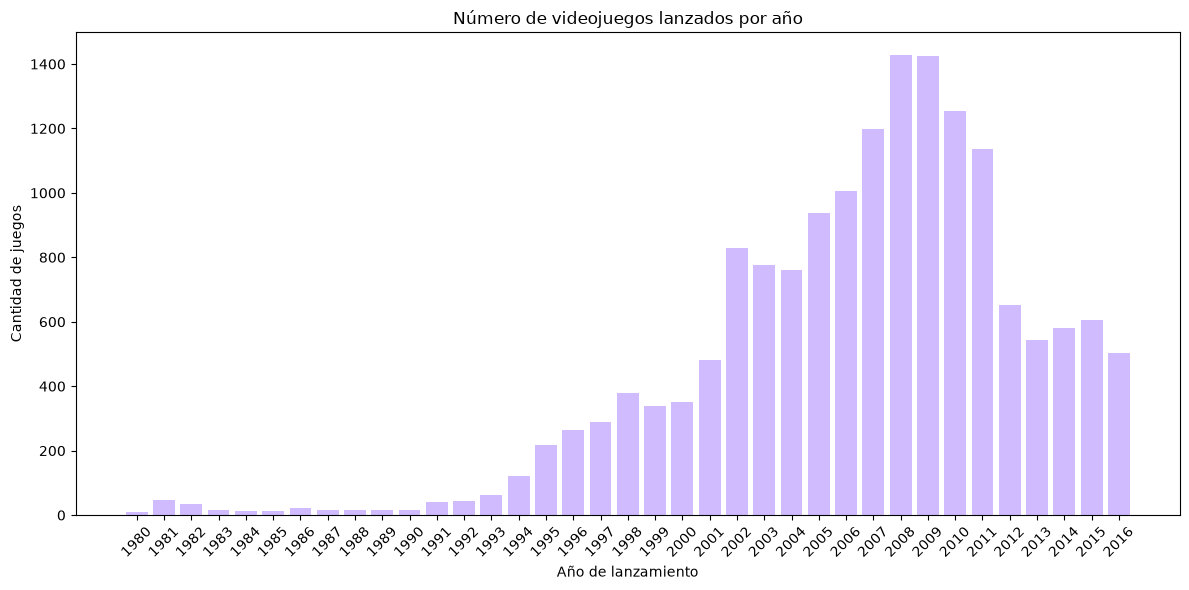

In [20]:
# Eliminación de videojuegos sin registro de año de lanzamiento
games_w_year = df[df['year_of_release'] != 0]

# Videojuegos lanzados por año
games_per_year = games_w_year.groupby('year_of_release')['name'].count()

# Gráfica
plt.figure(figsize=(12,6))
plt.bar(
    games_per_year.index,
    games_per_year.values,
    color=palette[4]
)

plt.title('Número de videojuegos lanzados por año')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Cantidad de juegos')

plt.xticks(games_per_year.index, rotation=45)
plt.tight_layout()
plt.show()

Para los videojuegos que tienen registrados el año de lanzamiento, sin considerar que los nombres se pueden repetir pero con diferente plataforma, vemos que 2008 y 2009 fueron los años en los que se lanzaron más videojuegos con valores de alrededor de 1,400.

<h1 style="color: #9370DB; font-size:15px">
   Ventas por plataforma
</h1>
Ahora vamos a evaluar como cambian las ventas segun la plataforma en la que se lanza el videojuego.

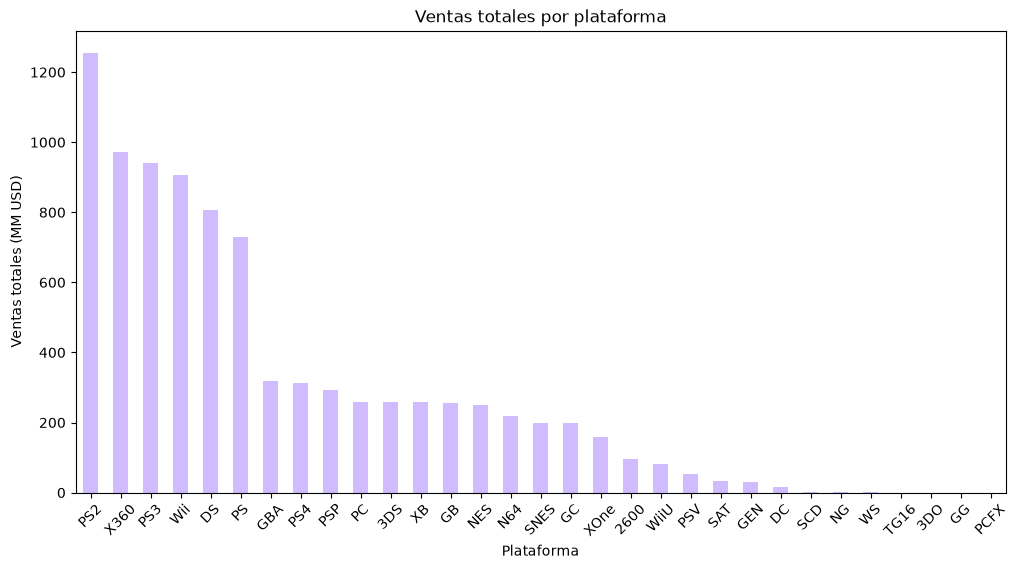

In [21]:
# Ventas totales por plataforma
df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).plot(kind='bar', figsize=(12,6), color=palette[4])

#Gráfica
plt.title('Ventas totales por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (MM USD)')
plt.xticks(rotation=45)
plt.show()

El PS2 es la plataforma con mayores ventas totales. Pero puede que algunas plataformas ya no tengan ventas, por lo que es necesario evaluar su desempeño a lo largo de los años.

<h1 style="color: #9370DB; font-size:15px">
    Comportamiento de las ventas a lo largo de los años por plataforma
</h1>
Ahora vamos a analizar como se comportan las ventas de cada plataforma según el año de lanzamiento del videojuego, considerando únicamente los videojuegos que tienen un año de lanzamiento registrado.

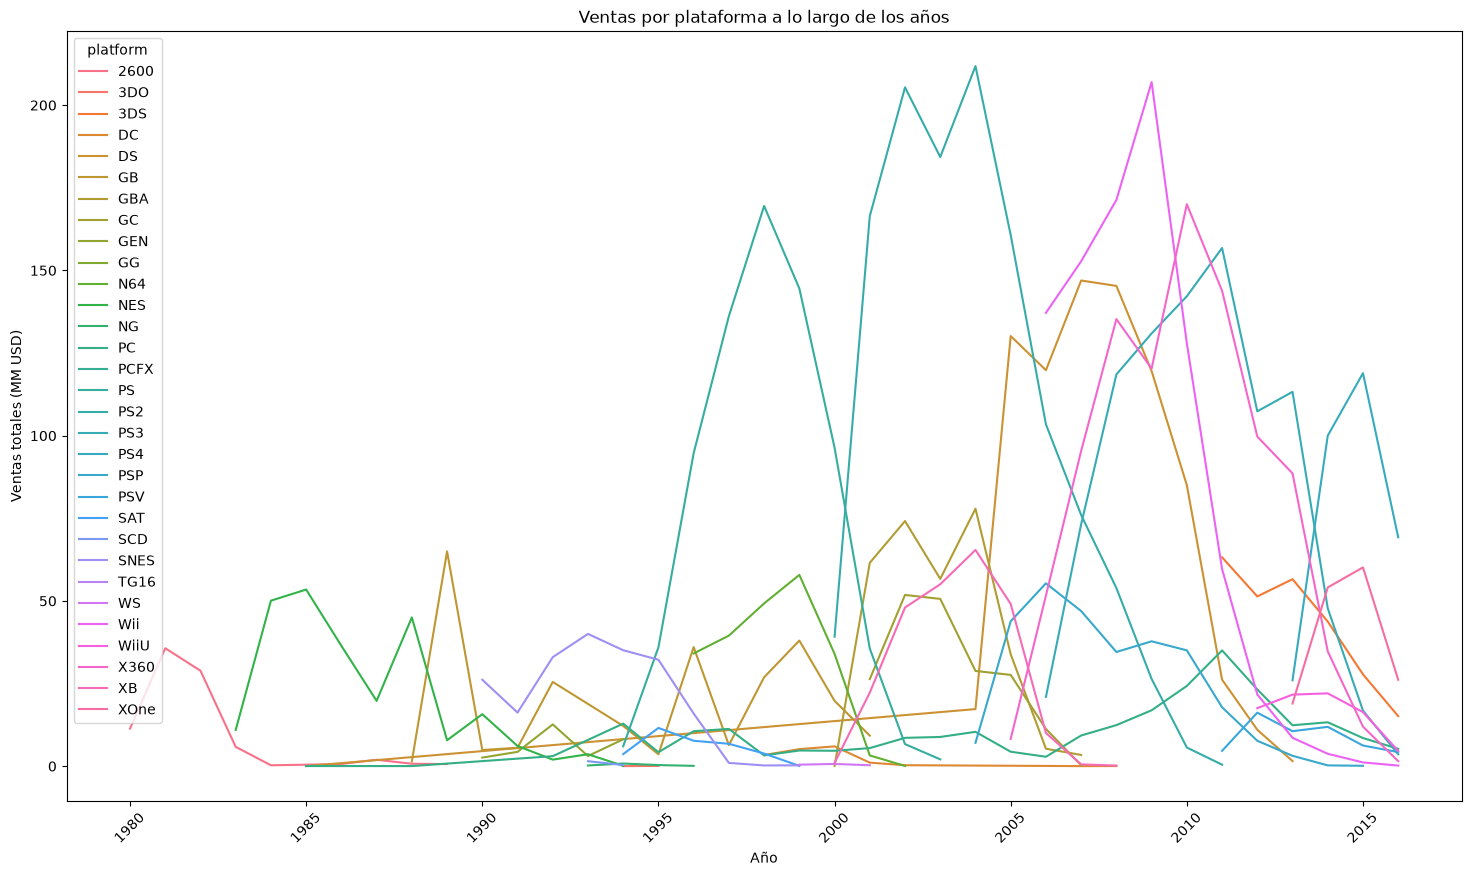

In [22]:
# Agrupar datos por plataforma y por año
ventas_por_plataforma = (games_w_year.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index())

# Gráfica
plt.figure(figsize=(18,10))

sns.lineplot(
    data=ventas_por_plataforma,
    x='year_of_release',
    y='total_sales',
    hue='platform'
)

plt.title('Ventas por plataforma a lo largo de los años')
plt.xlabel('Año')
plt.ylabel('Ventas totales (MM USD)')
plt.xticks(rotation=45)

plt.show()

Este resultado es algo caótico pero nos permite ver que las plataformas aparecen en el mercado, tienen un repunte y luego decaen y desaparecen nuevamente. Por eso vemos muchas campanas en lugar de lineas que crecen exponencialmente. Para poder llegar a conclusiones al respecto, es necesario buscar alterativas para evaluar la información, como puede ser de ayuda un Heatmap, que nos permite visualizar la vida util de cada plataforma, así como su comportamiento en cuanto a ventas a lo largo de los años. Para quitar todo el ruido posible podemos excluir las plataformas con menos ventas, como lo son las del extremo derecho del barplot de ventas totoales por plataforma, filtrando las ventas menores a 1.5 millones en ventas en total durante su vida útil.

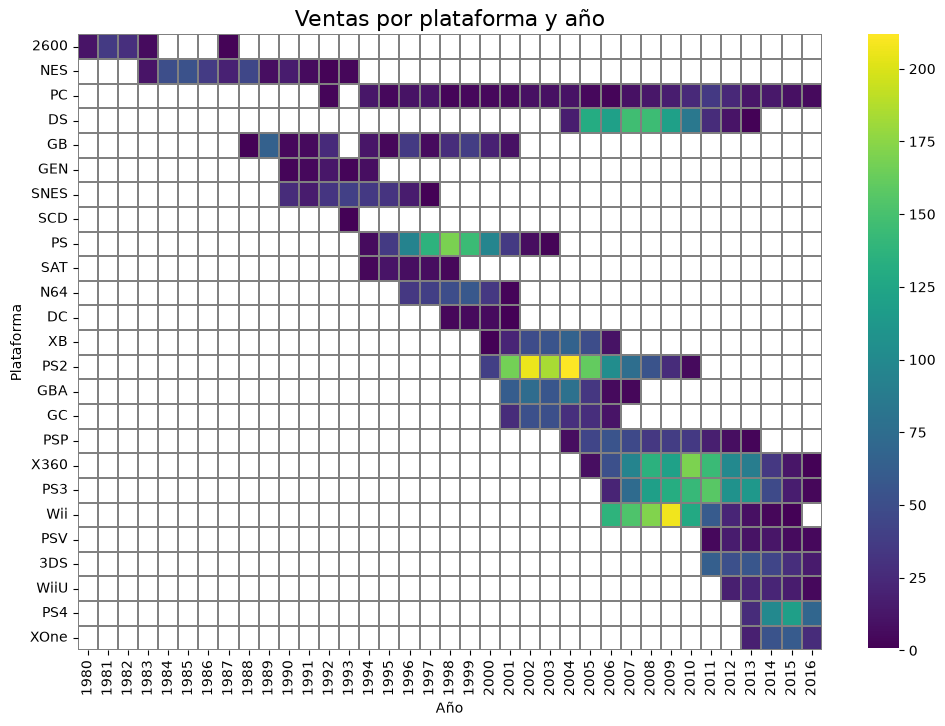

In [23]:
# 1. Agrupar ventas totales por plataforma y año
heatmap_data = games_w_year.groupby(
    ['platform', 'year_of_release']
)['total_sales'].sum().unstack(fill_value=0)

# 2. Quitar plataformas con ventas menores a 1.5 millones en las ventas totales de todos los años en los que lanzaron videojuegos
heatmap_data = heatmap_data[heatmap_data.sum(axis=1) > 1.5]

# 3. Ordenar plataformas por la primera aparición de ventas
platform_order = heatmap_data.apply(lambda row: row.ne(0).idxmax(), axis=1)
heatmap_data = heatmap_data.loc[platform_order.sort_values().index]

# 4. Crear colormap custom
base = plt.cm.viridis(np.linspace(0, 1, 256))
base[0] = [1, 1, 1, 1]
new_cmap = ListedColormap(base)

plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap=new_cmap,
    linewidths=0.3,
    linecolor='gray'
)

plt.title('Ventas por plataforma y año', fontsize=16)
plt.xlabel('Año')
plt.ylabel('Plataforma')
plt.show()

Aquí podemos ver el año en el que se lanzaron las diferentes plataformas y cuando dejaron de lanzar y/o vender juegos. Aquí es de vital importancia considerar que algunas plataformas corresponden a consolas de la misma empresa por lo que los ciclos se pueden considerar como parte de una misma fuente. Con estos valores, podemos considerar para el análisis los últimos 5 años de ventas. En cuanto a las plataformas podemos considerar aquellas que han tenido ventas en los últimos 3 años y aquellas que aun no han tenido su pico alto de ventas debido a que:

1.- Hay plataformas que no han tenido ventas en muchos años

2.- La vida útil de las que vendieron más de 100 millones anual fue de entre 10 y 11 años.

3.- Las plataformas que siguen teniendo ventas (a excepción de PC) y que aun no superan los 100 millones en ventas solo llevan existiendo desde 2011.

4.- De estas plataformas las más propmetedoras son PS4, PSV, XONE, WIU y 3DS, porque sus "antecesores" PS3, PS2, PS, X360, Wii y DS son las que superaron los 150 millones anuales, pero ya disminuyeron en ventas.

5.- Con estos criterios también debemos considerar la PC ya que se ha mantenido estable desde 1994, aunque sus ventas no sean tan elevadas como las consolas, debido a su naturaleza de accesibilidad y de adaptación al tiempo, es una plataforma confiable para seguir teniendo ventas.

<h1 style="color: #9370DB; font-size:15px">
    Datos para contruir un modelo para 2017
</h1>
Para comenzar tomaremos únicamente los datos de los últimos 5 años

In [24]:
# Creación de nuevo DataSet con valores de 2011 al 2016
df_last_5y = df[(df['year_of_release'] >= 2011) & (df['year_of_release'] <= 2016)]

<h1 style="color: #9370DB; font-size:15px">
    Plataformas potencialmente rentables
</h1>
Ahora vamos a filtrar por las plataformas más rentables

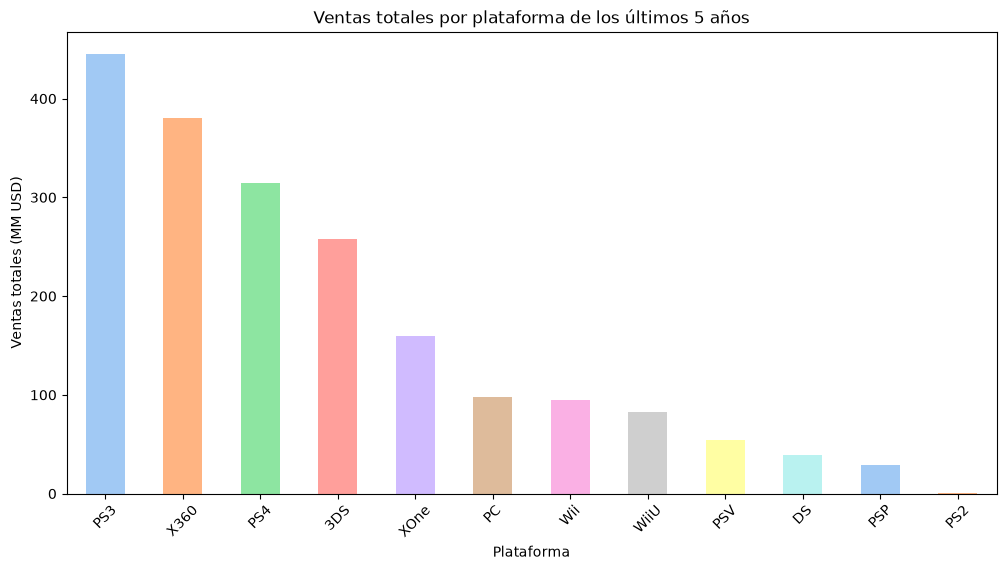

In [25]:
# Ventas totales por plataforma
df_last_5y.groupby('platform')['total_sales'].sum().sort_values(ascending=False).plot(kind='bar', figsize=(12,6), color=palette)

#Gráfica
plt.title('Ventas totales por plataforma de los últimos 5 años')
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (MM USD)')
plt.xticks(rotation=45)
plt.show()

En este caso usar un promedio para filtrar no va a ser una opción, ya que las mayores ventas las tiene PS3 y X360 que son plataformas que "van de salida", por lo que hay que filtrar el DataSet con las plataformas que siguen vigentes o que a penas van a repuntar.

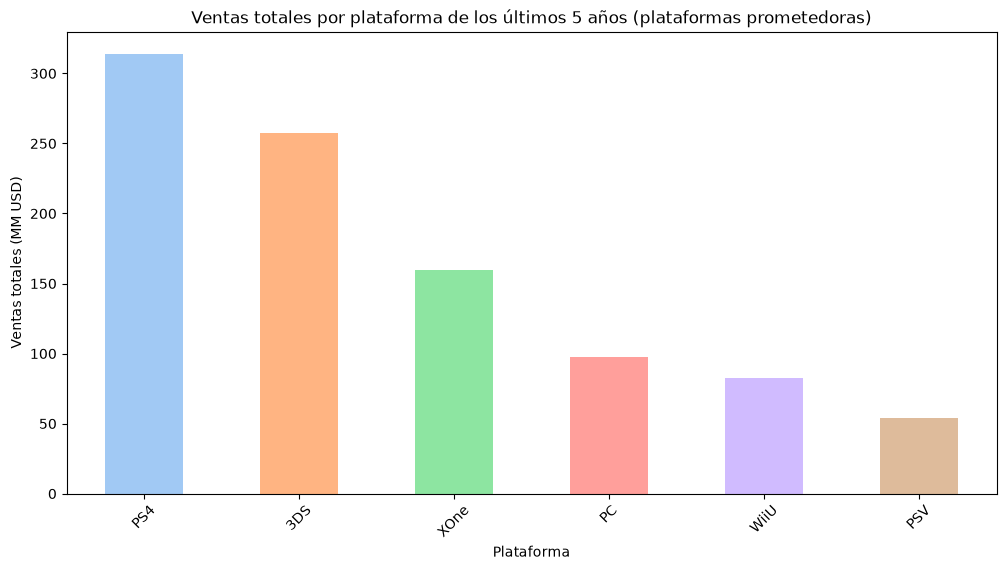

In [26]:
# Seleccionar únicamente plataformas relevantes
platforms_to_keep = ["PC", "PSV", "3DS", "WiiU", "PS4", "XOne"]
df_last_5y = df_last_5y[df_last_5y['platform'].isin(platforms_to_keep)]

# Graficamos para observar los datos con los que vamos a trabajar
df_last_5y.groupby('platform')['total_sales'].sum().sort_values(ascending=False).plot(kind='bar', figsize=(12,6), color=palette)

#Gráfica
plt.title('Ventas totales por plataforma de los últimos 5 años (plataformas prometedoras)')
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (MM USD)')
plt.xticks(rotation=45)
plt.show()

De las 6 plataformas seleccionadas, debemos tener en consideración que PC es la más antigua, mientras que PSV y 3DS lanzaron juegos a partir de 2011, WiiU en 2012, y PS4 y XOne en 2013 (es decir que estas dos son las más recientes). Sin embargo PS4 es el que más ventas a generado.

<h1 style="color: #9370DB; font-size:15px">
    Ventas globales por plataforma
</h1>

Utilizando el nuevo dataset de los años y plataformas relevantes, podemos analizar las ventas globales de todos los juegos y comparar las plataformas.

In [27]:
# Data set últimos 5 años
df_last_5y.nunique()

name               1558
platform              6
year_of_release       6
genre                12
na_sales            159
eu_sales            150
jp_sales             87
other_sales          75
critic_score         71
user_score           79
rating                6
total_sales         362
dtype: int64

/tmp/ipykernel_27317/2539539951.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


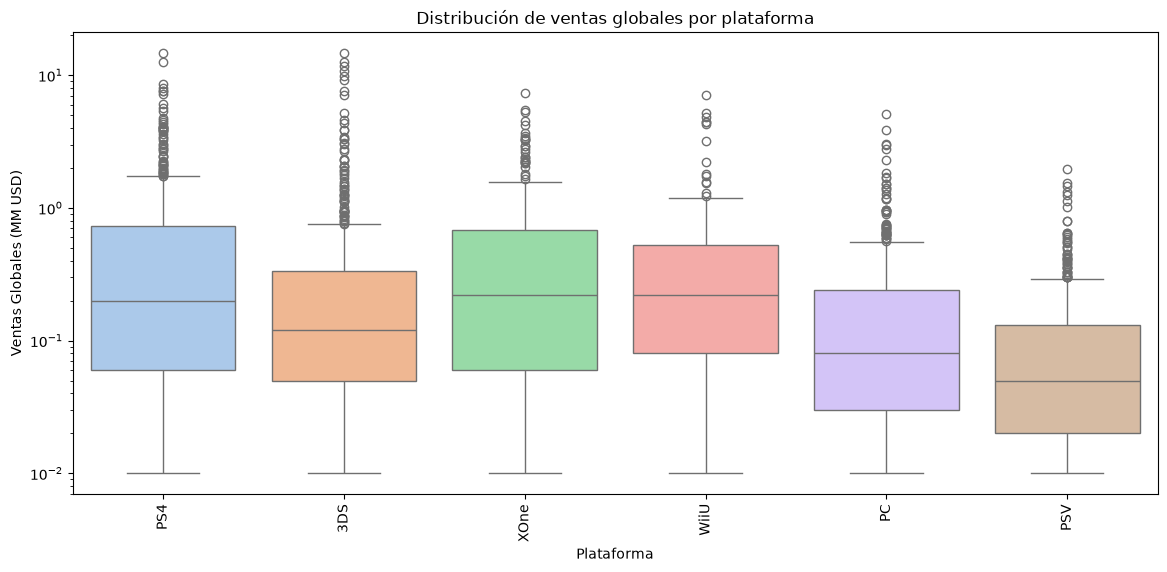

In [46]:
# Boxplot para comparar ventas globales por plataforma (con escala logarítmica)
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_last_5y,
    x='platform',
    y='total_sales',
    palette= 'pastel'
)

plt.yscale('log')

plt.title('Distribución de ventas globales por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Globales (MM USD)')
plt.xticks(rotation=90)
plt.show()

Aquí podemos observar que las plataformas tienen distribuciones similares en el rango intercuartílico, es decir que la mayoría de los títulos alcanzan niveles de ventas comparables. Sin embargo en los casos del PS4 y el 3DS se observa una mayor dispersión en ventas superiores, esto se puede atribuir a que tienen títulos con valores excepcionalmente altos considerados "Hits", es decir juegos a los cuales les va particularmente bien.

<h1 style="color: #9370DB; font-size:15px">
    Impacto de las reseñas de usuarios y profesionales
</h1> 
Algunos juegos obtienen calificaciones por parte de usuarios y/o por parte de profesionales. Estas calificaciones nos hablan de como es percibido el juego por el publico o por los usuarios. Podría asumirse que la "reputación" de un juego afecta sus ventas, para eso se puede realizar una prueba de correlación. Con la prueba de correlación podemos ver si hay alguna relación entre la calificación de cada juego y sus ventas totales, para determinar si los juegos mejor calificados venden más o no tienen relación alguna. Para relizar esta prueba se seleccionó la plataforma más popular, PS4, ya que es la plataforma con más ventas.

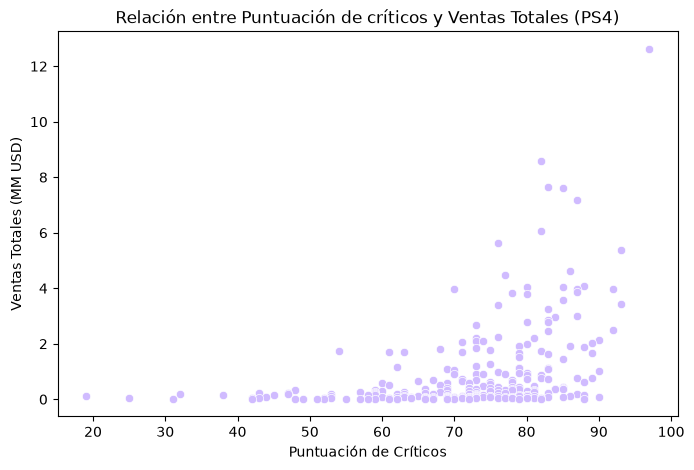

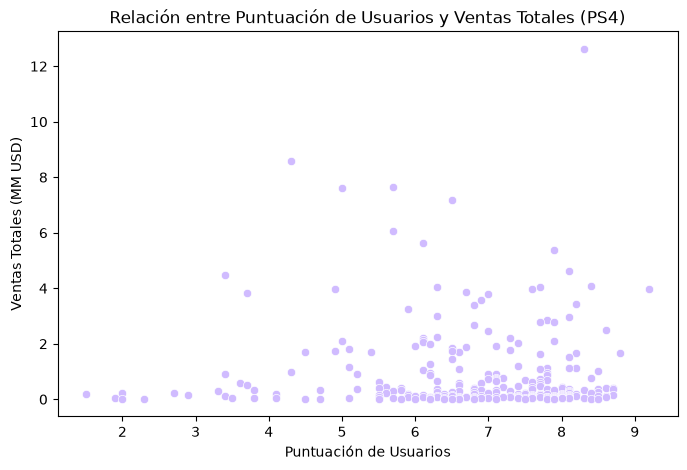

Correlación entre calificación de expertos y ventas: 0.40589480145836687
Correlación entre calificación de usuario y ventas: -0.03362497596528878


In [29]:
# Filtrado PS4
ps4 = df_last_5y[df_last_5y['platform'] == 'PS4'].copy()

#Correlación quitando valores sentinela
df_corr = ps4[
    (ps4['user_score'] != 11) &
    (ps4['critic_score'] != 0)
]

# Gráfico de dispersión critic_score
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_corr,
    x='critic_score',
    y='total_sales',
    color=sns.color_palette("pastel")[4]
)
plt.title('Relación entre Puntuación de críticos y Ventas Totales (PS4)')
plt.xlabel('Puntuación de Críticos')
plt.ylabel('Ventas Totales (MM USD)')
plt.show()

# Gráfico de dispersión user_score
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_corr,
    x='user_score',
    y='total_sales',
    color=sns.color_palette("pastel")[4]
)
plt.title('Relación entre Puntuación de Usuarios y Ventas Totales (PS4)')
plt.xlabel('Puntuación de Usuarios')
plt.ylabel('Ventas Totales (MM USD)')
plt.show()

# Correlación
cor_critic = df_corr['critic_score'].corr(df_corr['total_sales'])
cor_user = df_corr['user_score'].corr(df_corr['total_sales'])

print(f"Correlación entre calificación de expertos y ventas: {cor_critic}")
print(f"Correlación entre calificación de usuario y ventas: {cor_user}")

La correlación entre la calificación de expertos y las ventas de los juegos fue de 0.4059, lo que indica que a mejor calificación de los expertos, las ventas tienden a ser mayores. A pesar de no ser una correlación fuerte, puede considerarse relevante. Esto podría significar dos situaciones de causalidad, la primera podría ser que efectivamente la opinión de los expertos influye en la decisión de compra del usuario o la segunda que los juegos mejor calificados por expertos son juegos de mejor calidad, por lo tanto tendrán mejor desempeño en las ventas. Sin embargo debido a que el numero se acerca más al 0 que al 1, no se puede establecer que hay una relación de causa definitiva entre ambas.
Por otro lado, la correlación entre la calificación de usuarios y las ventas fue de -0.0336, al estar mucho más cercana al 0 indica que no hay relación entre la calificación de los usuarios y las ventas. Esto puede explicarse con el hecho de que las reseñas de usuarios son publicadas después de que el juego sale a la venta y ya llego al público general, por lo que su impacto puede ser atrasado y las criticas de los expertos previas al lanzamiente pueden ser de más peso. 

<h1 style="color: #9370DB; font-size:15px">
    Venta del mismo juego en diferentes plataformas 
</h1> 
Ahora que determinamos el impacto de otros factores en la venta de los juegos en la misma plataforma, procedemos a evaluar si las ventas del mismo juego cambian en distintas plataformas. Para eso vamos a tomar como ejemplo el juego con mayores ventas de PS4, para observar como fueron sus ventas en otras plataformas.

In [30]:
# COMPARACIÓN DE VENTAS DE LOS MISMOS JUEGOS EN DIFERENTES PLATAFORMAS
ps4 = df_last_5y[df_last_5y['platform'] == 'PS4']
best = ps4.loc[ps4['total_sales'].idxmax()]

# Detectar si tiene evaluación real o es sentinela
critic_eval = (
    "Sin evaluación de críticos"
    if best['critic_score'] == 0
    else best['critic_score']
)

user_eval = (
    "Sin evaluación de usuarios"
    if best['user_score'] == 11
    else best['user_score']
)

print("Juego más vendido de PS4:")
print(f"- Nombre: {best['name']}")
print(f"- Ventas totales: {best['total_sales']} millones")
print(f"- Críticos: {critic_eval}")
print(f"- Usuarios: {user_eval}")
print(f"- Año: {best['year_of_release']}")
print(f"- Género: {best['genre']}")

Juego más vendido de PS4:
- Nombre: Call of Duty: Black Ops 3
- Ventas totales: 14.629999999999999 millones
- Críticos: Sin evaluación de críticos
- Usuarios: Sin evaluación de usuarios
- Año: 2015
- Género: Shooter


El juego más vendido en PS4 fue Call of Duty: Black Ops 3 en 2015, no tiene críticas ni de usuarios ni de profesionales y recaudo un poco menos de 15 millones en ventas.
Como ejercicio extra para aterrizar las correlaciones obtenidas anteriormente podemos buscar cuál fue el juego mejor calificado.

In [31]:
# Filtrar solo donde SÍ hay evaluación real de críticos
ps4_valid_critics = ps4[ps4['critic_score'] != 0]

best_by_critics = ps4_valid_critics.loc[ps4_valid_critics['critic_score'].idxmax()]

print("Mejor calificado por críticos (PS4):")
print(f"- Nombre: {best_by_critics['name']}")
print(f"- User Score: {best_by_critics['user_score']}")
print(f"- Ventas: {best_by_critics['total_sales']} millones")
print(f"- Año: {best_by_critics['year_of_release']}\n")

# Filtrar solo donde SÍ hay evaluación real de usuarios
ps4_valid_users = ps4[ps4['user_score'] != 11]

best_by_users = ps4_valid_users.loc[ps4_valid_users['user_score'].idxmax()]

print("Mejor calificado por usuarios (PS4):")
print(f"- Nombre: {best_by_users['name']}")
print(f"- User Score: {best_by_users['user_score']}")
print(f"- Ventas: {best_by_users['total_sales']} millones")
print(f"- Año: {best_by_users['year_of_release']}")

Mejor calificado por críticos (PS4):
- Nombre: Grand Theft Auto V
- User Score: 8.3
- Ventas: 12.620000000000001 millones
- Año: 2014

Mejor calificado por usuarios (PS4):
- Nombre: The Witcher 3: Wild Hunt
- User Score: 9.2
- Ventas: 3.9699999999999998 millones
- Año: 2015


A modo de comprobación podemos observar como efectivamente el mejor calificado por los expertos, Grand Theft Auto V, recaudo casi 13 millones, muy cercano a lo recaudado por Call of Duty: Black Ops 3, contrario al caso del mejor calificado por usuarios, The Witcher 3: Wild Hunt, que en comparación recaudo unicamente cerca de 4 millones.

Ahora para comparar las ventas del mismo juego en diferentes plataformas podemos tomar como ejemplo Call of Duty: Black Ops3.

In [32]:
# Dataset unicamente con la información de Call of Duty: Black Ops 3.
cod_bo3 = df_last_5y[df_last_5y['name'] == 'Call of Duty: Black Ops 3'][['platform', 'total_sales']]

/tmp/ipykernel_27317/3728678921.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_27317/3728678921.py:4: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(


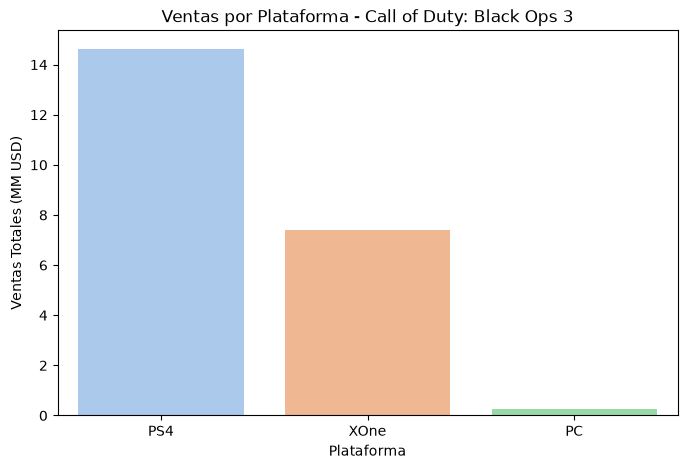

In [33]:
# Gráfica de barras para comparar la venta de Call of Duty: Black Ops 3 en diferentes plataformas
plt.figure(figsize=(8,5))

sns.barplot(
    data=cod_bo3,
    x='platform',
    y='total_sales',
    palette= palette
)

plt.title('Ventas por Plataforma - Call of Duty: Black Ops 3')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Totales (MM USD)')
plt.show()

Las ventas fueron considerablemente mayores en PS4, casi del doble que las ventas generadas por el mismo juego para XOne y muchisimo menores para PC. Esto indica que PS4 podría tener mejores ventas que las demás plataformas, siendo una mejor opción para lanzar juegos.

<h1 style="color: #9370DB; font-size:15px">
    Distribución general de los juegos por género
</h1> 
Otro análisis que puede dar información con respecto al comportamiento de las ventas, es determinar cuales son los géneros con más ventas.

/tmp/ipykernel_27317/2166917742.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_27317/2166917742.py:9: UserWarning: 
The palette list has fewer values (10) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


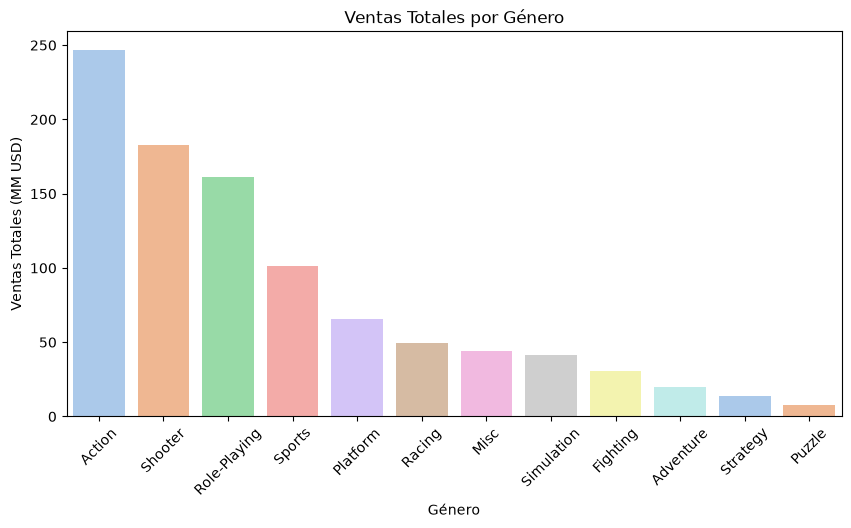

In [34]:
# Calcular las ventas totales por género
genre_tot_sales = (df_last_5y.groupby('genre')['total_sales'].sum().sort_values(ascending=False))

# Gráfica
genre_tot_sales_df = genre_tot_sales.reset_index()

plt.figure(figsize=(10,5))

sns.barplot(
    data=genre_tot_sales_df,
    x='genre',
    y='total_sales',
    palette=palette
)

plt.title('Ventas Totales por Género')
plt.ylabel('Ventas Totales (MM USD)')
plt.xlabel('Género')
plt.xticks(rotation=45)
plt.show()

Los géneros con mayores ventas en el periodo de estudio fueron Action, Shooter, Role-Playing, Sports, y Platform. De estos géneros el más vendido con 246.88 millones fue Action, a pesar de que hay diversos géneros y cada género tiene su público, es evidente que hay un género que vende más y géneros que tienen mayor preferencia. Sin embargo un solo factor no es suficiente para determinar si un juego tendrá éxito, como ejemplo tenemos el juego más vendido de Call of Duty: Black Ops 3, ya que es un juego de tipo Shooter, es el segundo género más vendido, a pesar de no ser el más alto si entra en los 5 géneros más vendidos. Es decir que si hay un patron de géneros con mayores ventass, pero es importante considerar que todos los géneros tienen su público.

<h1 style="color: #9370DB; font-size:18px">
   Análisis por región
</h1>
Otro análisis de gran utilidad, es separar los resultados por región, ya que el comportamiento de las ventas puede variar de una a otra.

<h1 style="color: #9370DB; font-size:15px">
    Plataformas principales por región, por cuota de mercadop
</h1> 
Para comenzar podemos analizar la diferencia del éxito de cada plataforma según la región, analizando las cuotas de mercado de las cinco principales plataformas, y ver como varian de región a región.

Para hacer el análisis por región, comenzamos por aislar la información relevante. Seguirimos trabajando sobre el dataframe de las plataformas más relevantes y de las ventas en los últimos 5 años, pero para analizar únicamente las 5 plataformas principales, vamos a eliminar los datos de PC ya que representa ventas muy bajas, dejandonos únicamente con: 'PS4', '3DS', 'XOne', 'WiiU' y 'PSV'. Además vamos a eliminar los juegos que no tienen ventas en cada región, debido a que los juegos que no generaron ventas en alguna región no participan en la couta de mercado.

In [35]:
# Dataframes para cada región, eliminando la plaTaforma 'PC' y los juegos que no tuvieron ventas en cada región.
df_na = df_last_5y[(df_last_5y['na_sales'] > 0) & 
                   (df_last_5y['platform'] != 'PC')].copy()

df_eu = df_last_5y[(df_last_5y['eu_sales'] > 0) & 
                   (df_last_5y['platform'] != 'PC')].copy()

df_jp = df_last_5y[(df_last_5y['jp_sales'] > 0) & 
                   (df_last_5y['platform'] != 'PC')].copy()

# Asignar colores a cada región para las gráficas.
custom_palette = [
    palette[0],  # NA
    palette[4],  # EU
    palette[7]   # JP
]

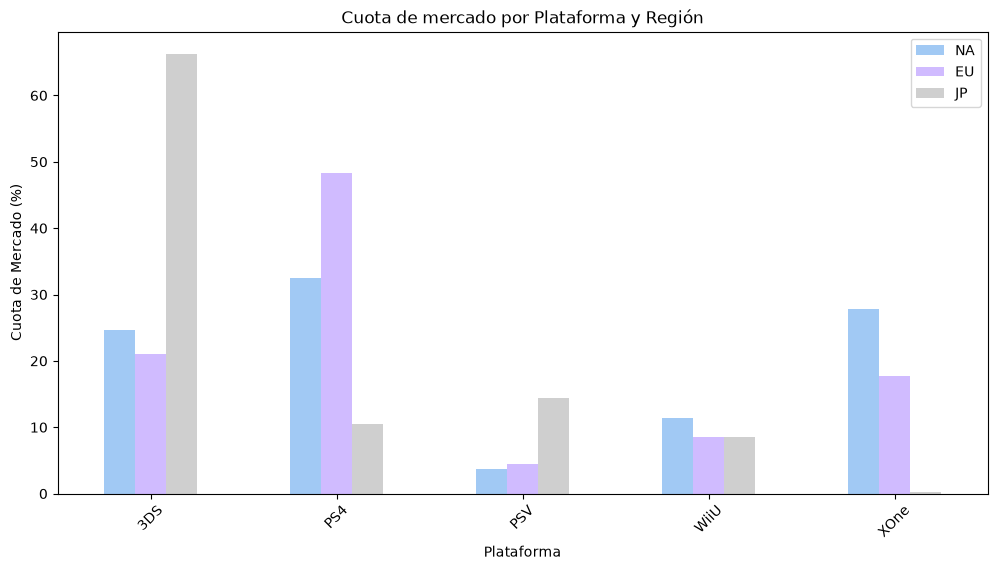

In [36]:
# Determinación de ventas por cada plataforma, para cada región
na_sales = (df_na.groupby('platform')['na_sales'].sum())
eu_sales = (df_eu.groupby('platform')['eu_sales'].sum())
jp_sales = (df_jp.groupby('platform')['jp_sales'].sum())

# Cálculo de la cuota de mercado de cada plataforma, por región
market_share_na = na_sales / na_sales.sum()
market_share_eu = eu_sales / eu_sales.sum()
market_share_jp = jp_sales / jp_sales.sum()

# Cuota en porcentaje
market_share_na = (market_share_na * 100).round(2)
market_share_eu = (market_share_eu * 100).round(2)
market_share_jp = (market_share_jp * 100).round(2)

# DF combinado con los resultados
market_share = pd.DataFrame({'NA': market_share_na,'EU': market_share_eu,'JP': market_share_jp}).fillna(0)

# Gráfica
market_share.plot(kind='bar', figsize=(12,6), color=custom_palette)
plt.title('Cuota de mercado por Plataforma y Región')
plt.ylabel('Cuota de Mercado (%)')
plt.xlabel('Plataforma')
plt.xticks(rotation=45)
plt.show()

En esta gráfica podemos observar en cada región región, que porcentaje de cuota de mercado representa cada una de las cinco plataformas, que determinamos previamente como las principales para el periodo de interés. En la región de Norteamérica la plataforma con la mayor cuota de mercado fue PS4, en competencia relativamente cercana con 3DS y XOne. En el caso de la región de Europa la plataforma con la mayor cuota de mercado fue PS4, representando casi la mitad, teniendo un éxitop superior sobre las demás platyaformas. Finalmente para el caso de japón, la plataforma con la mayor cuota de mercado por mucho es 3DS. Esto nos permite observar que las plataformas tienen diferentes relevancias en cada región, siendo en algunas competitivas. mientras que en otras regiones se ve una preferencia clara hacia una sobre el resto. Esto permite ajustar las estrategias de marqueting dependiendo de la región.

<h1 style="color: #9370DB; font-size:15px">
    Géneros principales
</h1> 
Después de ver las diferencias por plataforma, resulta interesante analizar las ventas de cada región por género. Primero hay que determinar si el TOP5 de géneros Global (action, shooter, role-playing, sports y platform) es igual en cada región, aunque la distribución de ventas o el orden sea distinto para cada una.

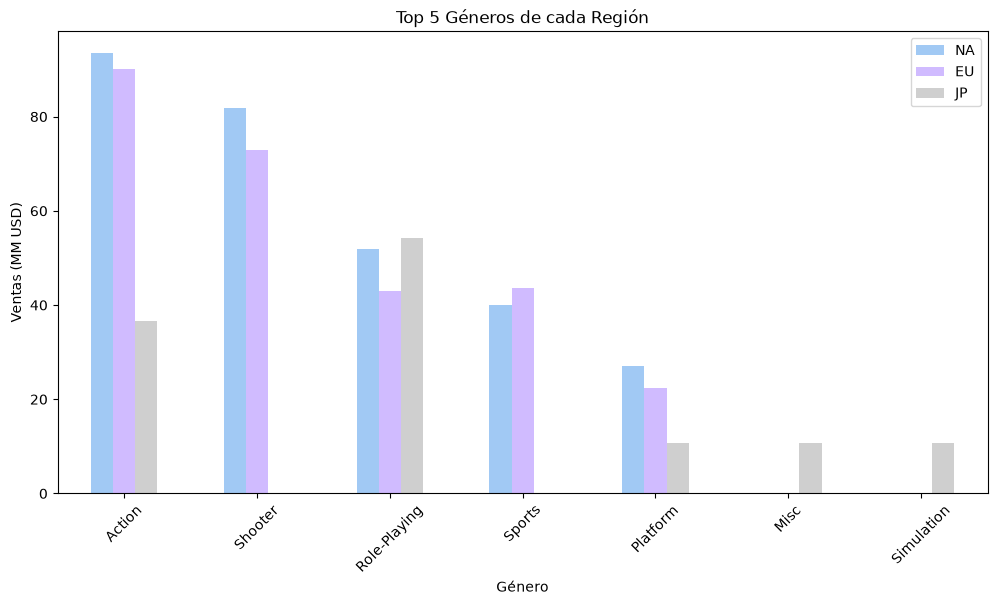

In [37]:
# Top 5 Norteamérica
top5_na_genres = (df_last_5y[df_last_5y['na_sales'] > 0].groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5))
# Top 5 Europa
top5_eu_genres = (df_last_5y[df_last_5y['eu_sales'] > 0].groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5))
# Top 5 Japón
top5_jp_genres = (df_last_5y[df_last_5y['jp_sales'] > 0].groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5))

# DF Combinado Top5 regional
top5_genres = pd.DataFrame({'NA': top5_na_genres,'EU': top5_eu_genres,'JP': top5_jp_genres}).fillna(0)
top5_genres_sorted = top5_genres.sort_values(by='NA', ascending=False)

# Gráfica
top5_genres_sorted.plot(kind='bar', figsize=(12,6), color=custom_palette)
plt.title('Top 5 Géneros de cada Región')
plt.ylabel('Ventas (MM USD)')
plt.xlabel('Género')
plt.xticks(rotation=45)
plt.show()

En principio podemos ver que los géneros populares en Norteamérica y en Europa son los mismos que el Top global, mientras que japón solo comparte Action, Role-playing y Platform, siendo los más populares los dos primeros. En este caso hay dos posibilidades para el departamento de marketing, una sería adecuar a cada región la promoción de juegos de erstos géneros, dandole prioridad a los de mayores ventas. La otra posibilidad es enforcase en los géneros que generan más de 20 millones de dolares de ventas, es decir el top global, y únicamente promocionar los de "Role-Playing" y "Action" en Japón.

Estas preferencias pueden estar intimamente ligadas con las culturas de cada región, sus creencias y sus intereses, por lo que es importante tenerlo en cuenta al realizar campañas publicitarias. Comprobando nuevamente que lo mejor es adecuar las campañas dependiendo de la región a la cual serán dirigidas.

<h1 style="color: #9370DB; font-size:15px">
    Efecto de las clasificaciones ESRB
</h1> 
Para completar el análisis por región, vamos a analizar si las clasificaciones ESBR afectan las ventas en cada región individualmente.

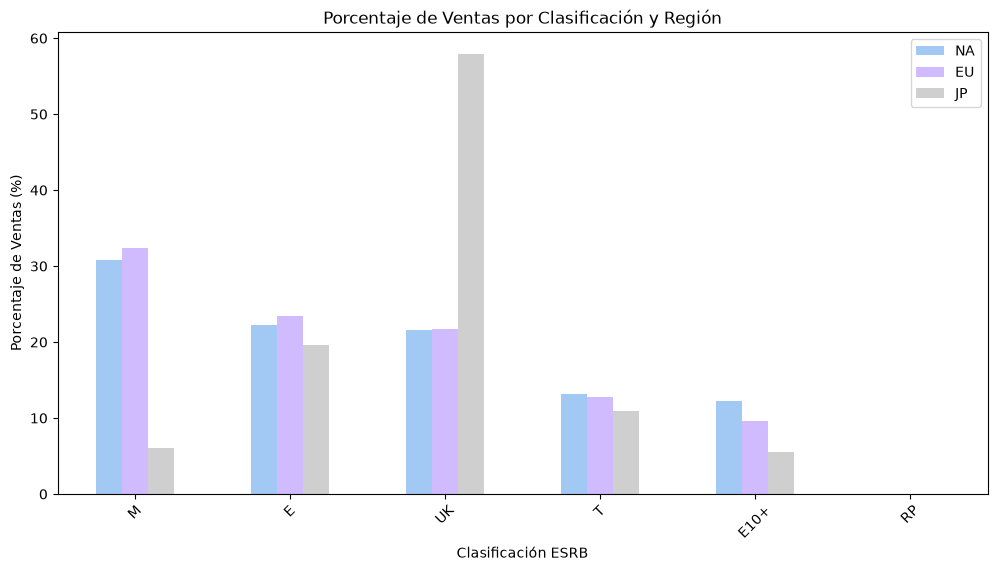

In [38]:
# Ventas por calificación por región
sales_per_rating_na = (df_last_5y.groupby('rating')['na_sales'].sum().sort_values(ascending=False))
sales_per_rating_eu = (df_last_5y.groupby('rating')['eu_sales'].sum().sort_values(ascending=False))
sales_per_rating_jp = (df_last_5y.groupby('rating')['jp_sales'].sum().sort_values(ascending=False))

# Porcentajes
share_na = ((sales_per_rating_na / sales_per_rating_na.sum()) * 100).round(2)
share_eu = ((sales_per_rating_eu / sales_per_rating_eu.sum()) * 100).round(2)
share_jp = ((sales_per_rating_jp / sales_per_rating_jp.sum()) * 100).round(2)

# DF combinado con los resultados
rating_share = pd.concat([share_na, share_eu, share_jp], axis=1)
rating_share.columns = ['NA', 'EU', 'JP']
rating_share = rating_share.fillna(0)

# Gráfica
rating_share.plot(kind='bar', figsize=(12,6), color=custom_palette)
plt.title('Porcentaje de Ventas por Clasificación y Región')
plt.ylabel('Porcentaje de Ventas (%)')
plt.xlabel('Clasificación ESRB')
plt.xticks(rotation=45)
plt.show()

Nuevamente se confirma que el comportamiento de las ventas es relativamente similar entre Norteamérica y Europa, y considerablemente distinto en Japón. En cuanto a la clasificación ESRB, tanto en Norteamérica como en Europa predominan las ventas de juegos con clasificación M (para mayores de 17 años), es decir, dirigidos a un público maduro. No obstante, la diferencia respecto a las demás clasificaciones no es excesivamente amplia, lo que sugiere una distribución relativamente equilibrada y la existencia de oferta para distintos segmentos de público.

En el caso de Japón, se observa que la categoría “Desconocido” (UK) es la que concentra la mayor proporción de ventas. Sin embargo, esta predominancia puede explicarse por diferencias en los sistemas de clasificación utilizados en cada región. Japón emplea un sistema propio que no necesariamente se alinea con el estándar ESRB, por lo que muchos títulos aparecen como “Unknown” en el conjunto de datos. En consecuencia, este resultado no implica que la clasificación no influya en las ventas, sino que refleja una diferencia metodológica en el registro de la información. Además, podría estar relacionado con la preferencia por géneros distintos a los predominantes en Norteamérica y Europa.

En conclusión en cuanto al análisis por región, este resultó ser muy valioso, ya que nos permitirá adaptar estrategias de ventas y de marketing a cada región específica.

<h1 style="color: #9370DB; font-size:18px">
   Prueba de hipótesis
</h1>
Finalmente se procede a llevar a cabo pruebas de hipótesis con el objetivo de determinar si existen diferencias estadísticamente significativas entre plataformas o géneros en relación con las calificaciones promedio otorgadas por los usuarios. Este enfoque permitirá evaluar, mediante una medida cuantificable, si la percepción y recepción de los jugadores varían según la plataforma o categoría del juego.

<h1 style="color: #9370DB; font-size:15px">
    Primer hipótesis - Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.
</h1> 
Lo primero que se debe hacer es preparar el dataframe con el cual se realizarán las pruebas estadísticas.

In [39]:
# Quitar valores sentinelas y crear dataframes para cada una de las plataformas
xone_scores = df_last_5y[
    (df_last_5y['platform'] == 'XOne') &
    (df_last_5y['user_score'] != 11)
]['user_score']

pc_scores = df_last_5y[
    (df_last_5y['platform'] == 'PC') &
    (df_last_5y['user_score'] != 11)
]['user_score']

<h1 style="color: #9370DB; font-size:15px">
    Prueba t<br>
    H0: Las medias de las calificaciones de usuarios en Xbox One y PC son iguales.<br>
    Ha: Las medias de las calificaciones de usuarios en Xbox One y PC son diferentes.
</h1>
Estas hipótesis se formularon de este modo ya que deseamos saber si las medias de dos poblaciones son iguales entre sí o no.

In [40]:
# Comprobamos si las varianzas son iguales o diferentes, previo a realizar la prueba t
st.levene(xone_scores, pc_scores)

LeveneResult(statistic=np.float64(5.516327585628806), pvalue=np.float64(0.019238606822498446))

Ya que 0.0192 < 0.05, las varianzas no son iguales, por lo tanto en la prueba t debemos agregar equal_var=False.<br>
La prueba se realizará usando alfa de 0.05 ya que es una medida comun de significación estadísitica y es aceptable para este tipo de análisis.

In [41]:
# Establecemos alfa 
alpha = 0.05  

#Prueba t
results = st.ttest_ind(xone_scores, pc_scores, equal_var=False) # realizar una prueba

print('valor p: ', results.pvalue) # extraer el valor p

if results.pvalue < alpha: # comparar el valor p con el umbral
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p:  0.6130712247638477
No podemos rechazar la hipótesis nula


Con base en los resultados no se rechaza la hipotesis nula, es decir que no existe evidencia estadísticamente significativa para afirmar que las calificaciones promedio de usuarios entre Xbox One y PC sean diferentes. Dado que no se encontraron diferencias estadísticamente significativas entre las calificaciones promedio de ambas plataformas, se puede inferir que la consola en la que se experimenta el juego no tiene un impacto observable en la valoración otorgada por los usuarios.

<h1 style="color: #9370DB; font-size:15px">
    Segunda hipótesis - Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.
</h1> 
Nuevamente preparamos el dataframe con el cual se realizarán las pruebas estadísticas.


In [42]:
# Quitar valores sentinelas y crear dataframes para cada uno de los géneros
action_scores = df_last_5y[
    (df_last_5y['genre'] == 'Action') &
    (df_last_5y['user_score'] != 11)
]['user_score']

sports_scores = df_last_5y[
    (df_last_5y['genre'] == 'Sports') &
    (df_last_5y['user_score'] != 11)
]['user_score']

<h1 style="color: #9370DB; font-size:15px">
    Prueba t<br>
    H0: Las medias de las calificaciones de usuarios en Acción y Deportes son iguales.<br>
    Ha: Las medias de las calificaciones de usuarios en Acción y Deportes son diferentes.
</h1>
Nuevamente, estas hipótesis se formularon de este modo ya que deseamos saber si las medias de dos poblaciones son iguales entre sí o no.

In [43]:
# Comprobamos si las varianzas son iguales o diferentes, previo a realizar la prueba t
st.levene(action_scores, sports_scores)

LeveneResult(statistic=np.float64(5.464170893275995), pvalue=np.float64(0.0198078418417402))

Ya que 0.0198 < 0.05, las varianzas son diferentes, por lo tanto en la prueba t debemos agregar equal_var=False.<br>
La prueba se realizará usando alfa de 0.05 ya que es una medida comun de significación estadísitica y es aceptable para este tipo de análisis.

In [44]:
# Establecemos alfa 
alpha = 0.05  

#Prueba t
results = st.ttest_ind(action_scores, sports_scores, equal_var=False) # realizar una prueba

print('valor p: ', results.pvalue) # extraer el valor p

if results.pvalue < alpha: # comparar el valor p con el umbral
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")


valor p:  1.8972540670913062e-10
Rechazamos la hipótesis nula


Con base en los resultados se rechaza la hipotesis nula, es decir existen diferencias estadísticamente significativas entre las calificaciones promedio de los usuarios para los géneros Acción y Deportes. Los resultados indican que los usuarios evalúan de manera distinta los juegos de Acción y Deportes, lo que sugiere diferencias en la percepción o satisfacción asociada a cada género.

<h1 style="color: #9370DB; font-size:18px">
   Conclusión general
</h1>
Para determinar si un juego tendrá éxito, es fundamental considerar los distintos factores que pueden influir en su desempeño comercial, como el género al que pertenece, la clasificación ESRB asignada, la plataforma en la que se lanza y la región en la que será comercializado.
Una vez en el mercado, es posible evaluar su recepción a través de las calificaciones de críticos y usuarios, lo que permite medir la percepción y el nivel de satisfacción del público.
Asimismo, el análisis comparativo con títulos similares resulta clave para identificar patrones en las ventas y estrategias implementadas previamente, evaluando cuáles fueron efectivas y cuáles no.
En conclusión, cada uno de estos factores desempeña un papel importante en el diseño de estrategias de marketing y ventas, contribuyendo de manera conjunta a aumentar la probabilidad de que un juego alcance el éxito esperado.